# Task 2 — Python Implementation of Classification Models
**10 Points** | Datasets: Breast Cancer (UCI) + Wine Quality (free choice)

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import label_binarize
from itertools import cycle


All libraries imported successfully.


## Dataset A — Breast Cancer (UCI)
569 samples, 30 features, 2 classes (malignant/benign)

In [2]:
def load_dataset_A():
    """Load and return Breast Cancer dataset as DataFrame."""
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    print(f'Dataset A (Breast Cancer): {df.shape[0]} samples, {df.shape[1]-1} features')
    print(f'Classes: {dict(zip(data.target_names, np.bincount(data.target)))}')
    print(f'Missing values: {df.isnull().sum().sum()}')
    return df, data.target_names

df_A, target_names_A = load_dataset_A()
df_A.head(3)

Dataset A (Breast Cancer): 569 samples, 30 features
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


## Dataset B — Wine Quality (Multi-class, 1599 samples, 11 features, 6 classes)

In [3]:
def load_dataset_B():
    """Load Wine Quality dataset from UCI. Falls back to synthetic if unavailable."""
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        df = pd.read_csv(url, sep=';')
        print(f'Dataset B (Wine Quality): loaded from UCI')
    except Exception:
        # Fallback: generate synthetic multi-class dataset
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=1200, n_features=11, n_informative=8,
            n_classes=4, n_clusters_per_class=1, random_state=42
        )
        df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(11)])
        df['quality'] = y
        print('Dataset B: using synthetic fallback (4 classes, 1200 samples)')

    # Bin wine quality scores into 3 classes for balance
    if 'quality' in df.columns and df['quality'].nunique() > 4:
        df['quality'] = pd.cut(df['quality'], bins=[0,5,6,10],
                               labels=[0,1,2]).astype(int)
    df = df.rename(columns={'quality': 'target'})
    print(f'Shape: {df.shape}, Classes: {df["target"].value_counts().to_dict()}')
    print(f'Missing values: {df.isnull().sum().sum()}')
    return df

df_B = load_dataset_B()
df_B.head(3)

Dataset B (Wine Quality): loaded from UCI
Shape: (1599, 12), Classes: {0: 744, 1: 638, 2: 217}
Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0


## 1. Data Preprocessing

In [4]:
def preprocess_dataset(df, target_col='target', test_size=0.15, val_size=0.15, random_state=42):
    """
    Full preprocessing pipeline.
    - Handles missing values via median imputation
    - Encodes categorical features
    - Normalizes numerical features with StandardScaler
    - Splits into train/val/test (70/15/15)
    """
    X = df.drop(columns=[target_col])
    y = df[target_col].values

    # Handle missing values — median for numeric
    for col in X.select_dtypes(include=[np.number]).columns:
        X[col].fillna(X[col].median(), inplace=True)

    # Encode categorical features
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # First split: train (70%) vs temp (30%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), stratify=y, random_state=random_state
    )
    # Second split: val (15%) vs test (15%) from temp
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=test_size / (test_size + val_size),
        stratify=y_temp, random_state=random_state
    )

    # Standardize — fit on train only to prevent data leakage
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    print(f'Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}')
    return X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, scaler

print('=== Dataset A ===' )
X_trA, X_vA, X_teA, y_trA, y_vA, y_teA, scA = preprocess_dataset(df_A)
print('\n=== Dataset B ===')
X_trB, X_vB, X_teB, y_trB, y_vB, y_teB, scB = preprocess_dataset(df_B)

=== Dataset A ===
Train: (398, 30), Val: (85, 30), Test: (86, 30)

=== Dataset B ===
Train: (1119, 11), Val: (240, 11), Test: (240, 11)


## 2. Model Training with Hyperparameter Tuning

In [5]:
def get_classifiers_and_params():
    """Return dict of (classifier, param_grid) for GridSearchCV."""
    return {
        'KNN': (
            KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7, 11], 'metric': ['euclidean', 'manhattan']}
        ),
        'Decision Tree': (
            DecisionTreeClassifier(random_state=42),
            {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy'],
             'min_samples_split': [2, 5]}
        ),
        'Random Forest': (
            RandomForestClassifier(random_state=42),
            {'n_estimators': [50, 100, 200], 'max_features': ['sqrt', 'log2'],
             'max_depth': [5, 10, None]}
        ),
        'SVM': (
            SVC(probability=True, random_state=42),
            {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
        ),
        'Logistic Regression': (
            LogisticRegression(max_iter=1000, random_state=42),
            {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
        ),
        'Naive Bayes': (
            GaussianNB(),
            {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
        ),
    }

def train_all_models(X_train, y_train, cv=5):
    """Train all classifiers with GridSearchCV and return best estimators."""
    classifiers = get_classifiers_and_params()
    best_models = {}

    for name, (clf, params) in classifiers.items():
        print(f'Tuning {name}...', end=' ')
        grid = GridSearchCV(clf, params, cv=cv, scoring='f1_weighted',
                            n_jobs=-1, refit=True)
        grid.fit(X_train, y_train)
        best_models[name] = grid.best_estimator_
        print(f'Best params: {grid.best_params_}')

    return best_models

print('=== Training on Dataset A ===')
models_A = train_all_models(X_trA, y_trA)
print('\n=== Training on Dataset B ===')
models_B = train_all_models(X_trB, y_trB)

=== Training on Dataset A ===
Tuning KNN... Best params: {'metric': 'manhattan', 'n_neighbors': 3}
Tuning Decision Tree... Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}
Tuning Random Forest... Best params: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Tuning SVM... Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Tuning Logistic Regression... Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuning Naive Bayes... Best params: {'var_smoothing': 1e-09}

=== Training on Dataset B ===
Tuning KNN... Best params: {'metric': 'euclidean', 'n_neighbors': 7}
Tuning Decision Tree... Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Tuning Random Forest... Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Tuning SVM... Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Tuning Logistic Regression... Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuning Naiv

## 3. Evaluation — Metrics, Confusion Matrix, ROC, Cross-Validation

=== Evaluating Dataset A ===


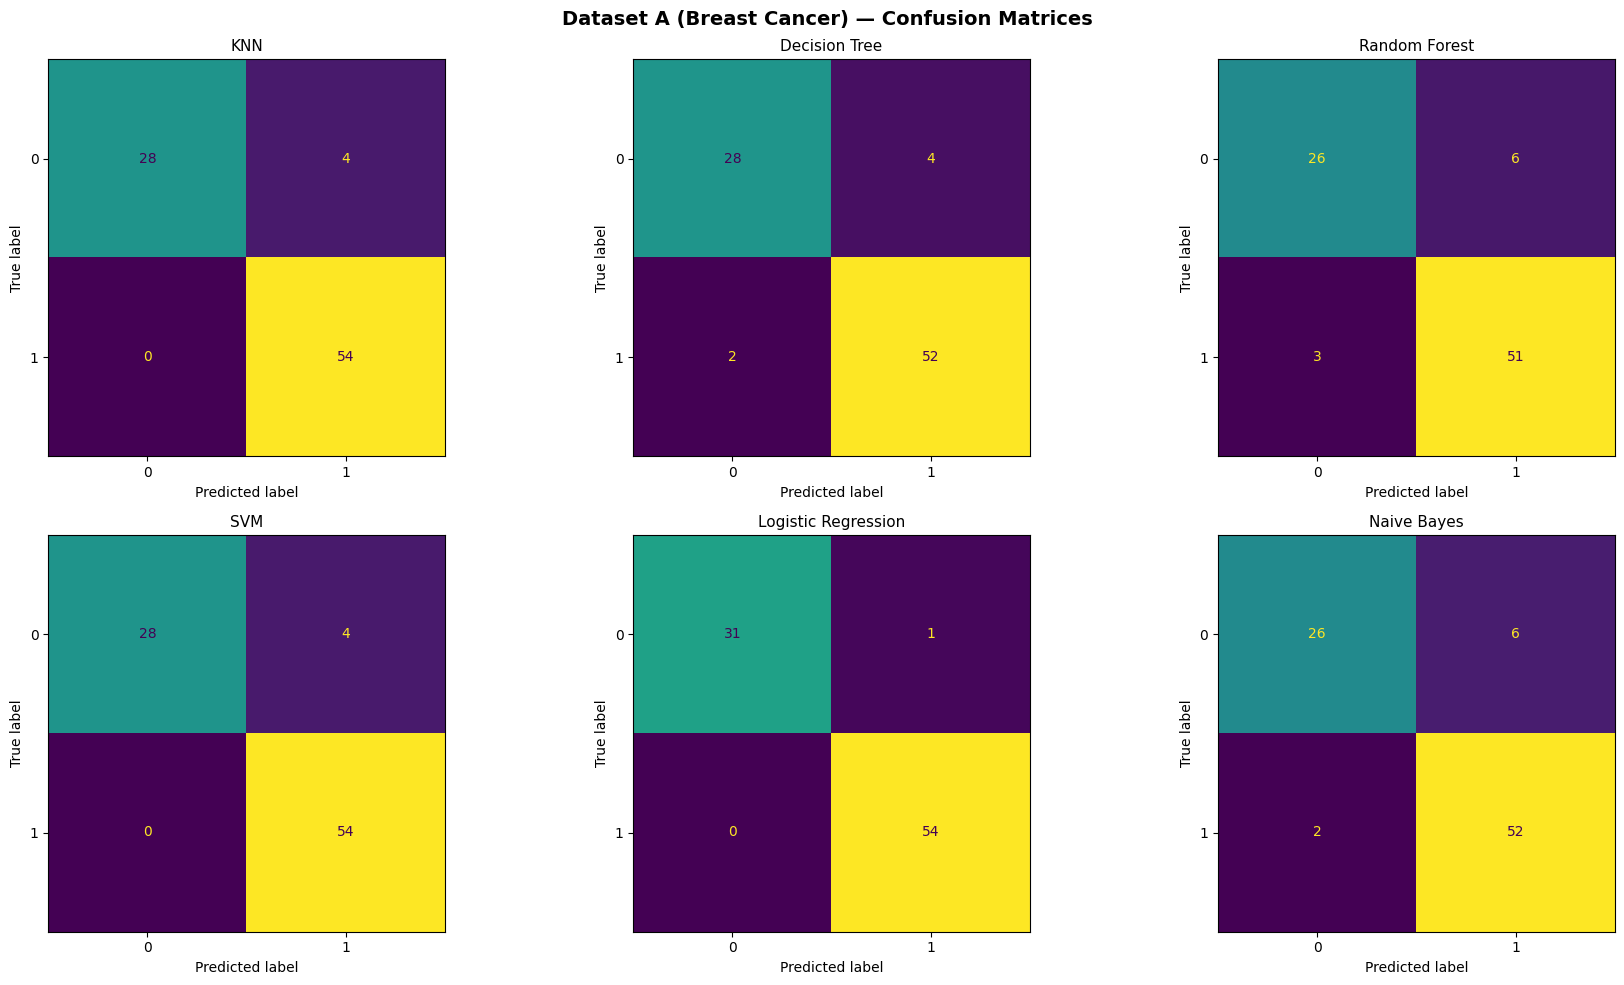

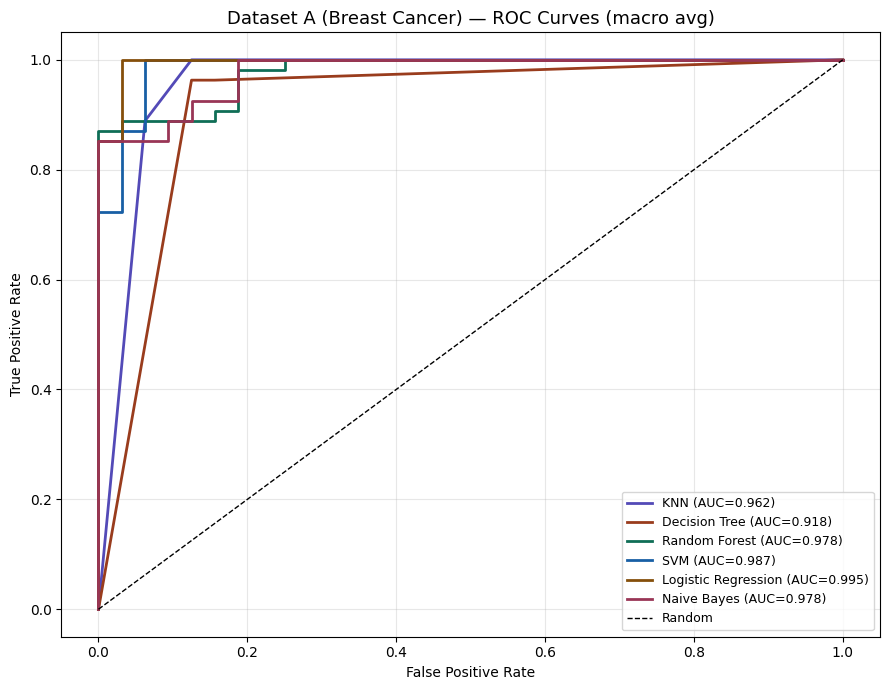


Dataset A (Breast Cancer) — Results Summary:
                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)   CV Mean (±std)
Model                                                                                                       
KNN                    0.9535             0.9655          0.9375      0.9488         0.9528  0.9724 ± 0.0200
Decision Tree          0.9302             0.9310          0.9190      0.9243         0.9297  0.9423 ± 0.0301
Random Forest          0.8953             0.8956          0.8785      0.8857         0.8942  0.9725 ± 0.0330
SVM                    0.9535             0.9655          0.9375      0.9488         0.9528  0.9774 ± 0.0050
Logistic Regression    0.9884             0.9909          0.9844      0.9875         0.9883  0.9799 ± 0.0150
Naive Bayes            0.9070             0.9126          0.8877      0.8976         0.9055  0.9322 ± 0.0291

=== Evaluating Dataset B ===


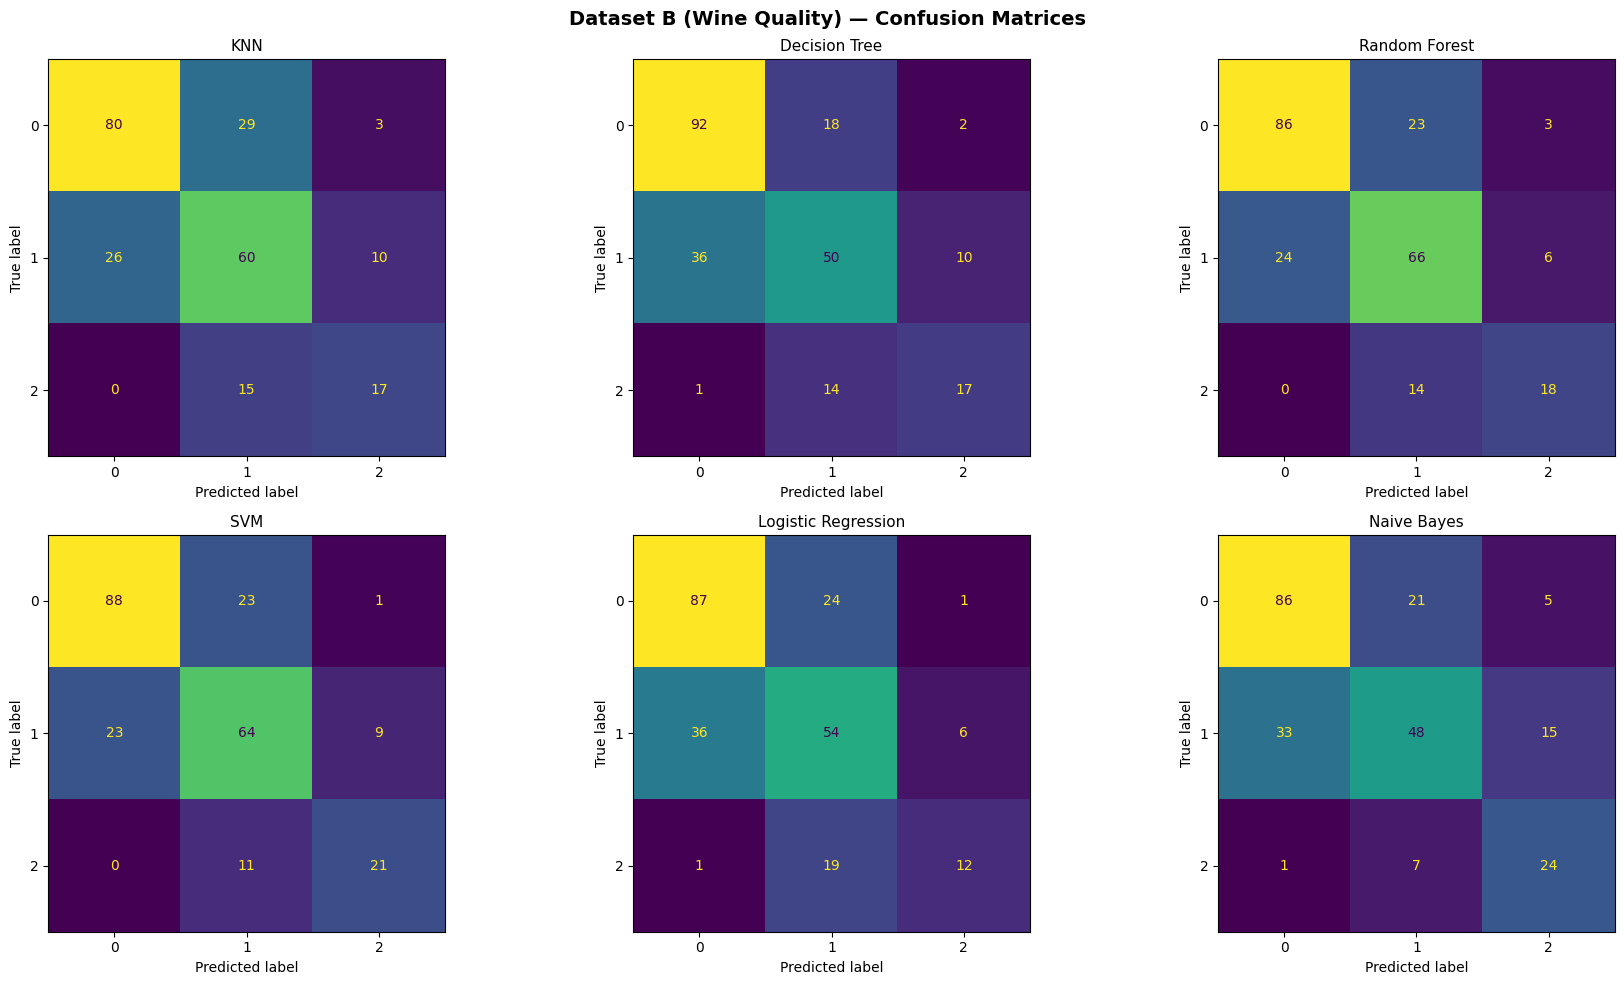

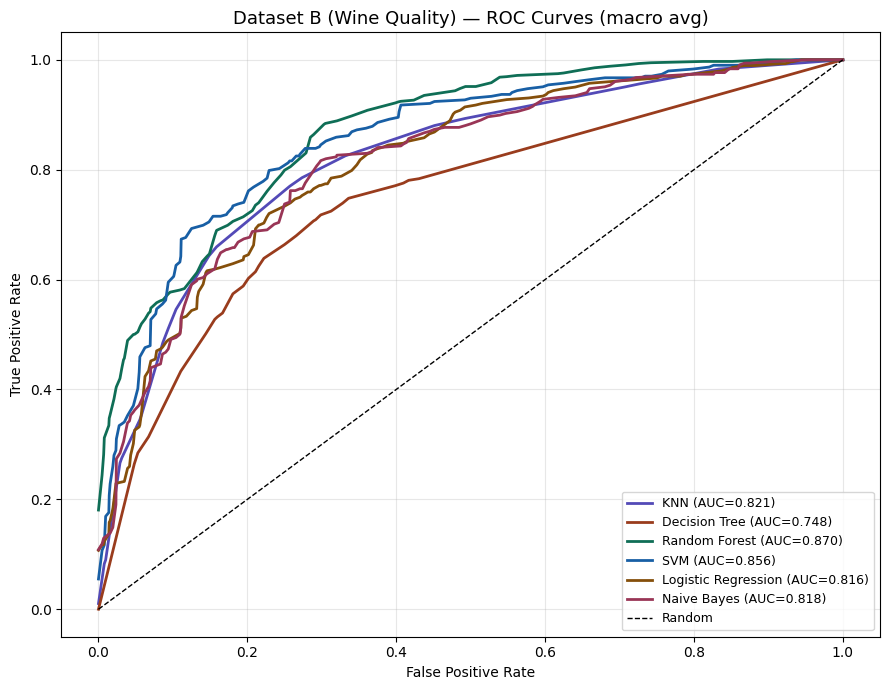


Dataset B (Wine Quality) — Results Summary:
                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)   CV Mean (±std)
Model                                                                                                       
KNN                    0.6542             0.6328          0.6235      0.6274         0.6556  0.5943 ± 0.0292
Decision Tree          0.6625             0.6364          0.6245      0.6276         0.6553  0.6166 ± 0.0215
Random Forest          0.7083             0.6964          0.6726      0.6828         0.7082  0.7051 ± 0.0200
SVM                    0.7208             0.7078          0.7029      0.7052         0.7211  0.6390 ± 0.0268
Logistic Regression    0.6375             0.6300          0.5714      0.5892         0.6306  0.6184 ± 0.0417
Naive Bayes            0.6583             0.6312          0.6726      0.6437         0.6534  0.5800 ± 0.0203


In [6]:
def evaluate_models(models, X_test, y_test, X_train, y_train, dataset_name='Dataset', cv=5):
    """Full evaluation: metrics, confusion matrices, ROC curves, CV scores."""
    results = []
    n_models = len(models)
    n_classes = len(np.unique(y_test))

    # --- Confusion Matrices ---
    fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 10))
    fig_cm.suptitle(f'{dataset_name} — Confusion Matrices', fontsize=14, fontweight='bold')

    # --- ROC Curves ---
    fig_roc, ax_roc = plt.subplots(figsize=(9, 7))
    ax_roc.set_title(f'{dataset_name} — ROC Curves (macro avg)', fontsize=13)
    colors_roc = ['#534AB7', '#993C1D', '#0F6E56', '#185FA5', '#854F0B', '#993556']

    for (name, clf), ax, color in zip(models.items(), axes_cm.flatten(), colors_roc):
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision (macro)': report['macro avg']['precision'],
            'Recall (macro)': report['macro avg']['recall'],
            'F1 (macro)': report['macro avg']['f1-score'],
            'F1 (weighted)': report['weighted avg']['f1-score'],
            f'CV Mean (±std)': f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
        })

        # Confusion matrix
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
        ax.set_title(name, fontsize=11)

        # ROC curve (macro OvR for multiclass)
        classes = np.unique(y_test)
        y_bin = label_binarize(y_test, classes=classes)
        if n_classes == 2:
            fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
        else:
            # Macro avg ROC
            all_fpr = np.unique(np.concatenate([
                roc_curve(y_bin[:, i], y_proba[:, i])[0] for i in range(n_classes)
            ]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_proba[:, i])
                mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
            mean_tpr /= n_classes
            macro_auc = auc(all_fpr, mean_tpr)
            ax_roc.plot(all_fpr, mean_tpr, color=color, lw=2,
                        label=f'{name} (AUC={macro_auc:.3f})')

    ax_roc.plot([0,1],[0,1],'k--', lw=1, label='Random')
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=9); ax_roc.grid(True, alpha=0.3)

    plt.figure(fig_cm.number); plt.tight_layout()
    plt.savefig(f'../results/task2_{dataset_name.lower().replace(" ","_")}_confusion.png',
                dpi=150, bbox_inches='tight')

    plt.figure(fig_roc.number); plt.tight_layout()
    plt.savefig(f'../results/task2_{dataset_name.lower().replace(" ","_")}_roc.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    results_df = pd.DataFrame(results).set_index('Model')
    print(f'\n{dataset_name} — Results Summary:')
    print(results_df.round(4).to_string())
    return results_df

print('=== Evaluating Dataset A ===')
results_A = evaluate_models(models_A, X_teA, y_teA, X_trA, y_trA, 'Dataset A (Breast Cancer)')

print('\n=== Evaluating Dataset B ===')
results_B = evaluate_models(models_B, X_teB, y_teB, X_trB, y_trB, 'Dataset B (Wine Quality)')

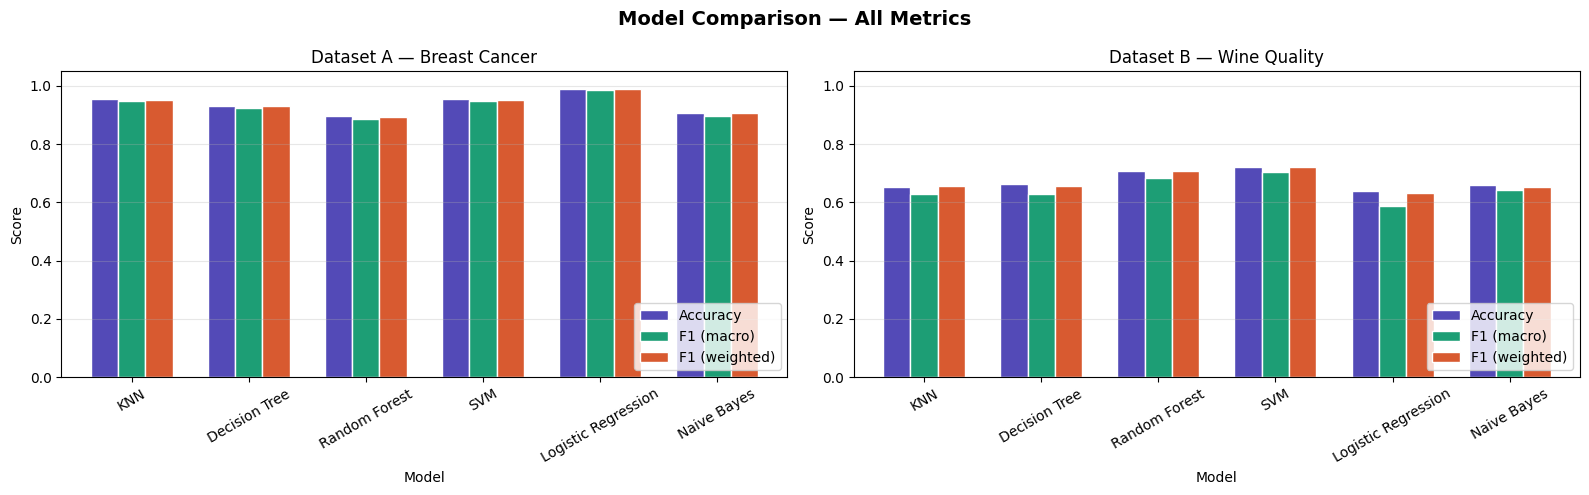

Best model Dataset A: Logistic Regression
Best model Dataset B: SVM
Best models saved.


In [7]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (results_df, title) in zip(axes, [
    (results_A, 'Dataset A — Breast Cancer'),
    (results_B, 'Dataset B — Wine Quality')
]):
    metrics = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
    data = results_df[metrics].astype(float)
    data.plot(kind='bar', ax=ax, color=['#534AB7', '#1D9E75', '#D85A30'],
              edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/task2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best models for Task 3
import pickle
best_A_name = results_A['F1 (weighted)'].astype(float).idxmax()
best_B_name = results_B['F1 (weighted)'].astype(float).idxmax()
print(f'Best model Dataset A: {best_A_name}')
print(f'Best model Dataset B: {best_B_name}')

with open('../results/best_model_A.pkl', 'wb') as f:
    pickle.dump(models_A[best_A_name], f)
with open('../results/best_model_B.pkl', 'wb') as f:
    pickle.dump(models_B[best_B_name], f)
print('Best models saved.')